In [2]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')    

import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *
from utils_data_vis import *

In [3]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

HORA_CRITICA_CH = "394717"

In [4]:
def plot_avg_deg(ax, dict_hora, limit_kt, axvline=None, xlabel=None, ylabel=None, alpha=0.7, dot_size=6, ylim=None):
    ax.set_facecolor('xkcd:white')
    for spine in ax.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax.get_xaxis().set_visible(True)
    ax.plot(list(dict_hora.keys())[0:limit_kt], list(dict_hora.values())[0:limit_kt], alpha=alpha)
    ax.scatter(list(dict_hora.keys())[0:limit_kt], list(dict_hora.values())[0:limit_kt], s=dot_size, alpha=alpha)
    if ylim:
        ax.set_ylim(ylim[0], ylim[1])
    if axvline:
        ax.axvline(axvline, ls="--")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=20)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=20)

In [5]:
def plot_clust_ss(ax, arr_kt_plot, dict_norm_int_deg, xlim=None, ylim=(0.1, 1.05), legend=True, marker="x", alpha=0.7, ylabel=None, xlabel=None, sep_points=1, loc=None, linewidth=0.6, s=4):
	
	for kt in arr_kt_plot[:]:
		if kt in dict_norm_int_deg.keys():
			points_x = list(dict_norm_int_deg[kt].keys())[::sep_points]
			points_y = list(dict_norm_int_deg[kt].values())[::sep_points]
			# Se quita el 0 para que la visualizacións se más clara
			if float(0) in dict_norm_int_deg[kt].keys():
				points_x = points_x[1:]
				points_y = points_y[1:]

			points_y, indexes = calcular_quitar_ceros(points_y)
			points_x, _ = quitar_ceros(points_x, indexes)
	
			ax.plot(points_x, points_y, alpha=alpha, linewidth=linewidth)
			ax.scatter(points_x, points_y, alpha=alpha, s=1, marker=marker, label=f'$k_T: {kt}$')        
	ax.set_ylabel(ylabel, fontsize=20)
	ax.set_xlabel(xlabel, fontsize=20)
		
	ax.set_xscale('log')  
	ax.set_yscale('log')  
	ax.set_ylim(ylim[0], ylim[1])
	ax.set_xlim(xlim[0], xlim[1])
	if loc:
		ax.legend(loc=loc, prop={'size': 12})
	else:
		ax.legend(prop={'size': 12})
	ax.grid(True, which="both", ls="--", linewidth=0.5)

In [6]:
def _exp_bin_xy(x, y, aa=1.02, normalize=False):
    """
    Binning exponencial para pares (x,y).
    - aa: factor de crecimiento del tamaño de bin (1.02 por defecto, como en make_exponential_binning.py)
    - normalize=True: divide por el ancho del bin (útil si 'y' es densidad - PDF).
    Devuelve arrays (xb, yb) con el centro del bin (media geométrica) y el valor agregado.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    xmax = float(x.max())
    i = 1
    xs, ys = [], []
    while aa**i <= xmax:
        lo = aa**i
        hi = aa**(i + 1)

        # Mismo truco que el script: evitar bordes exactamente enteros
        if float(int(lo)) == lo:
            lo -= 0.1
        if float(int(hi)) == hi:
            hi += 0.1

        sel = (x > lo) & (x <= hi)
        if np.any(sel):
            xg = math.sqrt(lo * hi)          # centro del bin (media geométrica)
            if normalize:                     # para PDFs: sumar y normalizar por ancho
                yb = y[sel].sum() / (hi - lo)
            else:                             # para CCDF: media dentro del bin (suavizado)
                yb = y[sel].mean()
            xs.append(xg); ys.append(yb)
        i += 1

    return np.array(xs), np.array(ys)

In [7]:
def plot_pdf_expbin(ax, arr_xy, arr_kt_plot, aa=1.02, ylabel=None,
					ylim=(0.0002, 1.05), xlim=None,
					marker="x", alpha=0.7, dot_size=2, line=True,
					normalize=False, label_prefix="$k_t :$ "):
	"""
	Versión con binning exponencial del plot.
	- arr_xy: lista de (x, y) como arr_ccdf_points_* o arr_pdf_points_*.
	- normalize=True si 'y' es PDF (densidad) y quieres dividir por ancho del bin.
	"""
	for idx, (x, y) in enumerate(arr_xy):
		xb, yb = _exp_bin_xy(x, y, aa=aa, normalize=normalize)
		if xb.size == 0:
			continue

		# Filtrar puntos problemáticos (y <= 0) para escala log
		mask = yb > 0
		xb = xb[mask]
		yb = yb[mask]
		if xb.size == 0:
			continue

		ax.plot(
			xb, yb,
			marker=marker,
			ms=dot_size,
			alpha=alpha,
			lw=0.8 if line else 0,
			linestyle='-' if line else 'none',
			label=f"{label_prefix}{arr_kt_plot[idx]}",
		)
		ax.scatter(
			xb, yb,
			s=2,
			marker=marker,
			alpha=alpha,
		)
	ax.set_xscale('log')
	ax.set_yscale('log')
	if ylim: ax.set_ylim(*ylim)
	if xlim: ax.set_xlim(*xlim)
	if ylabel: ax.set_ylabel(ylabel, fontsize=20)
	ax.grid(True, which="both", ls="--", linewidth=0.5)

In [8]:
def _exp_bin_xy_ss(x, y, aa=1.02):
    """
    Binning exponencial para pares (x, y).
    - aa: factor de crecimiento de los bins (1.02 por defecto).
    - x>0, y finitos. El punto del bin se coloca en la media geométrica del intervalo.
    Devuelve (xb, yb) con un valor y agregado como media dentro del bin.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    xmax = float(x.max())
    i = 1
    xs, ys = [], []
    while aa**i <= xmax:
        lo = aa**i
        hi = aa**(i + 1)

        # Evitar bordes exactamente enteros (mismo truco que el script original)
        if float(int(lo)) == lo:
            lo -= 0.1
        if float(int(hi)) == hi:
            hi += 0.1

        sel = (x > lo) & (x <= hi)
        if np.any(sel):
            xg = math.sqrt(lo * hi)   # centro del bin (media geométrica)
            yb = y[sel].mean()        # agregador para clustering: media
            xs.append(xg); ys.append(yb)
        i += 1

    return np.array(xs), np.array(ys)

In [9]:
def plot_clust_ss_expbin(ax, arr_kt_plot, dict_norm_int_deg,
						 aa=1.02, xlim=None, ylim=(0.01, 1.05),
						 alpha=0.7, marker="x", linewidth=0.8, s=10,
						 legend=True, loc=None, title=None,
						 ylabel=None, xlabel=None):
	"""
	Versión con binning exponencial del plot tipo plot_clust_ss.

	Parámetros clave:
	- arr_kt_plot: lista con los k_T a graficar (orden de las curvas).
	- dict_norm_int_deg: dict: kt -> {grado: valor} (p.ej., clustering normalizado por grado).
	- aa: factor del exponential binning (1.02 por defecto).
	- Los demás parámetros controlan estilo y ejes.
	"""
	for kt in arr_kt_plot:
		if kt not in dict_norm_int_deg:
			continue

		# Extraer pares (grado, valor)
		# Nota: dict puede no estar ordenado; para el binning no hace falta orden.
		x_vals = np.array(list(dict_norm_int_deg[kt].keys()), dtype=float)
		y_vals = np.array(list(dict_norm_int_deg[kt].values()), dtype=float)

		# Limpiar: quitar grado=0 y no finitos; también y<=0 si vas a usar escala log en Y
		m = (x_vals > 0) & np.isfinite(x_vals) & np.isfinite(y_vals) & (y_vals > 0)
		x_vals = x_vals[m]; y_vals = y_vals[m]
		if x_vals.size == 0:
			continue

		xb, yb = _exp_bin_xy_ss(x_vals, y_vals, aa=aa)
		if xb.size == 0:
			continue

		# Línea + puntos (como el original)
		ax.plot(xb, yb, alpha=alpha, linewidth=linewidth, marker=marker, ms=s)
		ax.scatter(xb, yb, alpha=alpha, s=s, marker=marker, label=f'$k_T: {kt}$')

	# Escalas log–log (habitual para grado y clustering con límites como 0.01–1.05)
	ax.set_xscale('log')
	ax.set_yscale('log')

	if title:
		ax.set_title(title, fontsize=20)
	if ylabel:
		ax.set_ylabel(ylabel, fontsize=20)
	if xlabel:
		ax.set_xlabel(xlabel, fontsize=20)

	if ylim:
		ax.set_ylim(ylim[0], ylim[1])
	if xlim:
		ax.set_xlim(xlim[0], xlim[1])

	if legend:
		if loc:
			ax.legend(loc=loc, prop={'size': 12})
		else:
			ax.legend(prop={'size': 12})
	ax.grid(True, which="both", ls="--", linewidth=0.5)

In [10]:
def calc_degree_distribution(hour, manifestacion, graphs_folder="graphs/", mode="h", measures_folder="measures/", G=None, arr_kt=[0], exp=False, read=True, write=True, norm=False, thresh_filt=5):
    if mode == "h":
        path_graph = "nodes_hashtag/"
    elif mode == "f":
        path_graph = "nodes_filtered/" + str(thresh_filt) + '/'
    
    G = nx.read_gexf(graphs_folder + path_graph + manifestacion + hour + '.gexf')
        
    arr_points = []
    dict_points = {}
    
    # Si no recibe un arr_kt como parametro, se interpreta que es la red original
    for kt in tqdm(arr_kt):
        points_kt=[0]
        if not kt in dict_points.keys():
            F = thresh_normalization(G, kt)
            if F != -1:
                points_kt = np.sort(np.array(list(dict(F.degree()).values())).astype(float))
                dict_points[kt] = list(points_kt)
                """for index, point in enumerate(points_kt):
                    if kt== 0:
                        print(kt, point, ':', point / np.mean(points_kt), sorted(F.nodes[node]["internalDegree"] for node in F.nodes())[index])"""
    
        else:
            points_kt = dict_points[kt]
        if norm:
            points_kt = np.array(points_kt) / np.mean(points_kt)
        arr_points.append(points_kt)
    # El exponente solo se va a calcular cuando se reciba un valor de kt
    plfit = None
    if exp:
        # Para calcular el exponente no hay que normalizar
        plfit = get_exp([dict_points[arr_kt[0]]])

    # Puntos de la PDF
    arr_deg_prob = []
    for points in arr_points:
        degrees, counts = np.unique(points, return_counts=True)
        probs = counts / len(points)
        arr_deg_prob.append((degrees, probs))
        #print(degrees)
        #print(probs)
    
    # Puntos de la CDF
    arr_deg_cum = []
    for deg_prob in arr_deg_prob:
        cum_freq = np.cumsum(deg_prob[1])
        cdf = cum_freq/cum_freq[-1]
        arr_deg_cum.append((deg_prob[0], cdf))
        #print(cdf)
    # Puntos de la CCDF
    arr_deg_comp_cum = []
    for deg_cum in arr_deg_cum:
        ccdf = 1 - deg_cum[1]
        arr_deg_comp_cum.append((deg_cum[0], ccdf))
        #print(ccdf)

    return plfit, arr_deg_prob, arr_deg_comp_cum

In [11]:
def calc_avg_clust_coef_by_internal_degree(G, clust):
    dict_hid_var_aux = {}
    dict_hid_var = {}
    # Crea un diccionario con cada internal degree como clave y un array con los coeficientes
    # de clusterización de los nodos que tienen dicho internal degree

    for node in G.nodes():
        att = G.nodes[node]["internalDegree"]
        if att in dict_hid_var_aux.keys():
            np.append(dict_hid_var_aux[att], clust[node])
        else:
            dict_hid_var_aux[att] = np.array(clust[node])

    # Se ordena el diccionario en función de la clave (internal degree) de menor a mayor
    # sorted(dict) devuleve las keys ordenadas
    dict_hid_var_aux_2 = {k: dict_hid_var_aux[k] for k in sorted(dict_hid_var_aux)}

    # Se crea un diccionario con internal degrees como clave y la media de coeficiente de clusterización
    # de los nodos que tienen dicho internal degree como valor
    for key in dict_hid_var_aux_2.keys():
        dict_hid_var[key] = np.average(dict_hid_var_aux_2[key])
    return dict_hid_var

In [12]:
def add_hidden_variable(F):
    avg_deg = calc_avg_degree(F)
    if avg_deg != 0:
        dict_hidd_var = {}
        for node in F.nodes():
            dict_hidd_var[node] = F.degree[node]
        nx.set_node_attributes(F, dict_hidd_var, "internalDegree")
    else:
        return -1

def thresh(G, threshold):
    # Se añaden solamente los nodos que cumplan el umbral
    F = add_nodes_subgraph(G, threshold)
    
    # Si ya no hay nodos que cumplan el umbral, se acaba el proceso
    if F.number_of_nodes() == 0:
        return -1
    
    # Ahora se añaden las aristas de G de los nodos en el subgrafo F
    F = add_edges_subgraph(G, F)

    # Se añade como variable oculta el grado entre la media del grafo a cada nodo
    if add_hidden_variable(F) == -1:
        return -1
    
    return F


def calc_clust(hora, MAX_UMBRAL, manifestacion, path_graph):
    G = nx.read_gexf(graphs_folder + path_graph  + manifestacion + hora + ".gexf")
    dict_thres_avg_clust = {}
    dict_int_deg = {}

    # Se calculan las sucesivas métricas para cada umbral de grado y se escriben
    for threshold in tqdm(range(MAX_UMBRAL)):
        flag_int_deg = threshold in dict_int_deg.keys()
        flag_avg_clust = threshold in dict_thres_avg_clust.keys()
        # Si ambas son true podemos saltar el paso (ya está calculado previamente)
        if not (flag_int_deg and flag_avg_clust):
            # Se crea el subgrafo basándonos en el threshold seleccionado
            F = thresh(G, threshold)
            if F == -1:
                return dict_thres_avg_clust, dict_int_deg

            clust  = nx.clustering(F)
            avg_clust = np.mean(np.array(list(clust.values())))
            dict_thres_avg_clust[threshold] = avg_clust

            dict_int_deg[threshold] = calc_avg_clust_coef_by_internal_degree(F, clust)
       
    return dict_thres_avg_clust, dict_int_deg

In [13]:
hour_window_ch = 2

# Sin filtrar

In [14]:
limit_kt_ch_h = 50
critical_kt_ch_h = 15
arr_kt_plot_ch_h = [0,7,9,11,13,15]

dict_avg_deg_ch_h = get_avg_deg_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="hashtag", MAX_UMBRAL=200)

100%|██████████| 200/200 [00:00<00:00, 1720.62it/s]


## Sin filtrar sin reescalar

In [15]:
_, arr_pdf_points_ch_h_noreescale, arr_ccdf_points_ch_h_noreescale = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=False, read=False)
dict_thres_avg_clust_ch_h_noreescale, dict_norm_int_deg_ch_h_noreescale = calc_clust(HORA_CRITICA_CH, 200, "ch/" + str(hour_window_ch) + '/', "nodes_hashtag/")

100%|██████████| 200/200 [00:00<00:00, 595.30it/s]


## Sin filtrar reescalado

In [16]:
_, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True, read=False)
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, 200, "ch/" + str(hour_window_ch) + '/')

100%|██████████| 200/200 [00:00<00:00, 276.78it/s]


# Filtrado

In [17]:
umbral_ch = 3

limit_kt_ch_f = 30
critical_kt_ch_f = 5
arr_kt_plot_ch_f = [0,1,2,3,4,5]

MAX_UMBRAL = 200
dict_avg_deg_ch_f = get_avg_deg_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)


 19%|█▉        | 38/200 [00:00<00:00, 10663.25it/s]


## Filtrado sin reescalar

In [18]:
_, arr_pdf_points_ch_f_noreescale, arr_ccdf_points_ch_f_noreescale = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="f", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_f, exp=False, norm=False, read=False)
dict_thres_avg_clust_ch_f_noreescale, dict_norm_int_deg_ch_f_noreescale = calc_clust(HORA_CRITICA_CH, 200, "ch/" + str(hour_window_ch) + '/', "nodes_filtered/" + str(umbral_ch) + '/')

 19%|█▉        | 38/200 [00:00<00:00, 3259.44it/s]


## Filtrado reescalado

In [19]:
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)
dict_thres_avg_clust_ch_f, dict_norm_int_deg_ch_f = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)

100%|██████████| 6/6 [00:00<00:00, 2029.67it/s]


Calculating best minimal value for power law fit


 19%|█▉        | 38/200 [00:00<00:00, 1485.37it/s]


# Otra hora

In [20]:
OTRA_HORA_CH = str(int(HORA_CRITICA_CH)-72)
umbral_ch_o = 1
arr_kt_plot_ch_o = [0,2,4,6,8,10]
limit_kt_ch_o = 30
critical_kt_ch_o = 20

dict_avg_deg_ch_o = get_avg_deg_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)


 19%|█▉        | 38/200 [00:00<00:00, 9314.68it/s]


## Sin reescalar

In [21]:
_, arr_pdf_points_ch_o_noreescale, arr_ccdf_points_ch_o_noreescale = calc_degree_distribution(OTRA_HORA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=False, read=False)
dict_thres_avg_clust_ch_o_noreescale, dict_norm_int_deg_ch_o_noreescale = calc_clust(OTRA_HORA_CH, 200, "ch/" + str(hour_window_ch) + '/', "nodes_hashtag/")

 63%|██████▎   | 126/200 [00:00<00:00, 1074.98it/s]


## Reescalada

In [22]:
plfit_ch_o, arr_pdf_points_ch_o, arr_ccdf_points_ch_o = calc_degree_distribution(OTRA_HORA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)
dict_thres_avg_clust_ch_o, dict_norm_int_deg_ch_o = calc_self_sim(OTRA_HORA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)

_, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(OTRA_HORA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True, read=False)
dict_thres_avg_clust_ch_o, dict_norm_int_deg_ch_o = calc_self_sim(OTRA_HORA_CH, 200, "ch/" + str(hour_window_ch) + '/')

100%|██████████| 6/6 [00:00<00:00, 14372.26it/s]


Calculating best minimal value for power law fit


 63%|██████▎   | 126/200 [00:00<00:00, 509.44it/s]


# plot

In [23]:
# Red sin filtrar
### Sin reescalar
xlim_ch_h_n = (0, 600)
ylim_ch_h_n = (0.0002, 1.05)
### Reescalando
xlim_ch_h = (0.024, 100)
ylim_ch_h = (0.0002, 1.05)
### Exp binning
xlim_ch_h_e = (0.5, 100)

# Red filtrada
### Sin reescalar
xlim_ch_f_n = (0, 600)
ylim_ch_f_n = (0.0002, 1.05)
### Reescalando
xlim_ch_f = (0.1, 30)
ylim_ch_f = (0.0002, 1.05)
### Exp binning
xlim_ch_f_e = (0.5, 50)

# Otra hora sin filtrar
### Sin reescalar
xlim_ch_o_n = (0, 600)
ylim_ch_o_n = (0.0002, 1.05)
### Reescalando
xlim_ch_o = (0.1, 30)
ylim_ch_o = (0.0002, 1.05)
### Exp binning
xlim_ch_o_e = (0.5, 50)




/tmp/ipykernel_9785/2389483020.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[0].set_xlim(xlim_ch_h_n[0], xlim_ch_h_n[1])
/tmp/ipykernel_9785/2975213399.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(xlim[0], xlim[1])
/tmp/ipykernel_9785/2389483020.py:90: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[6].set_xlim(xlim_ch_f_n[0], xlim_ch_f_n[1])
/tmp/ipykernel_9785/2389483020.py:144: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[12].set_xlim(xlim_ch_o_n[0], xlim_ch_o_n[1])


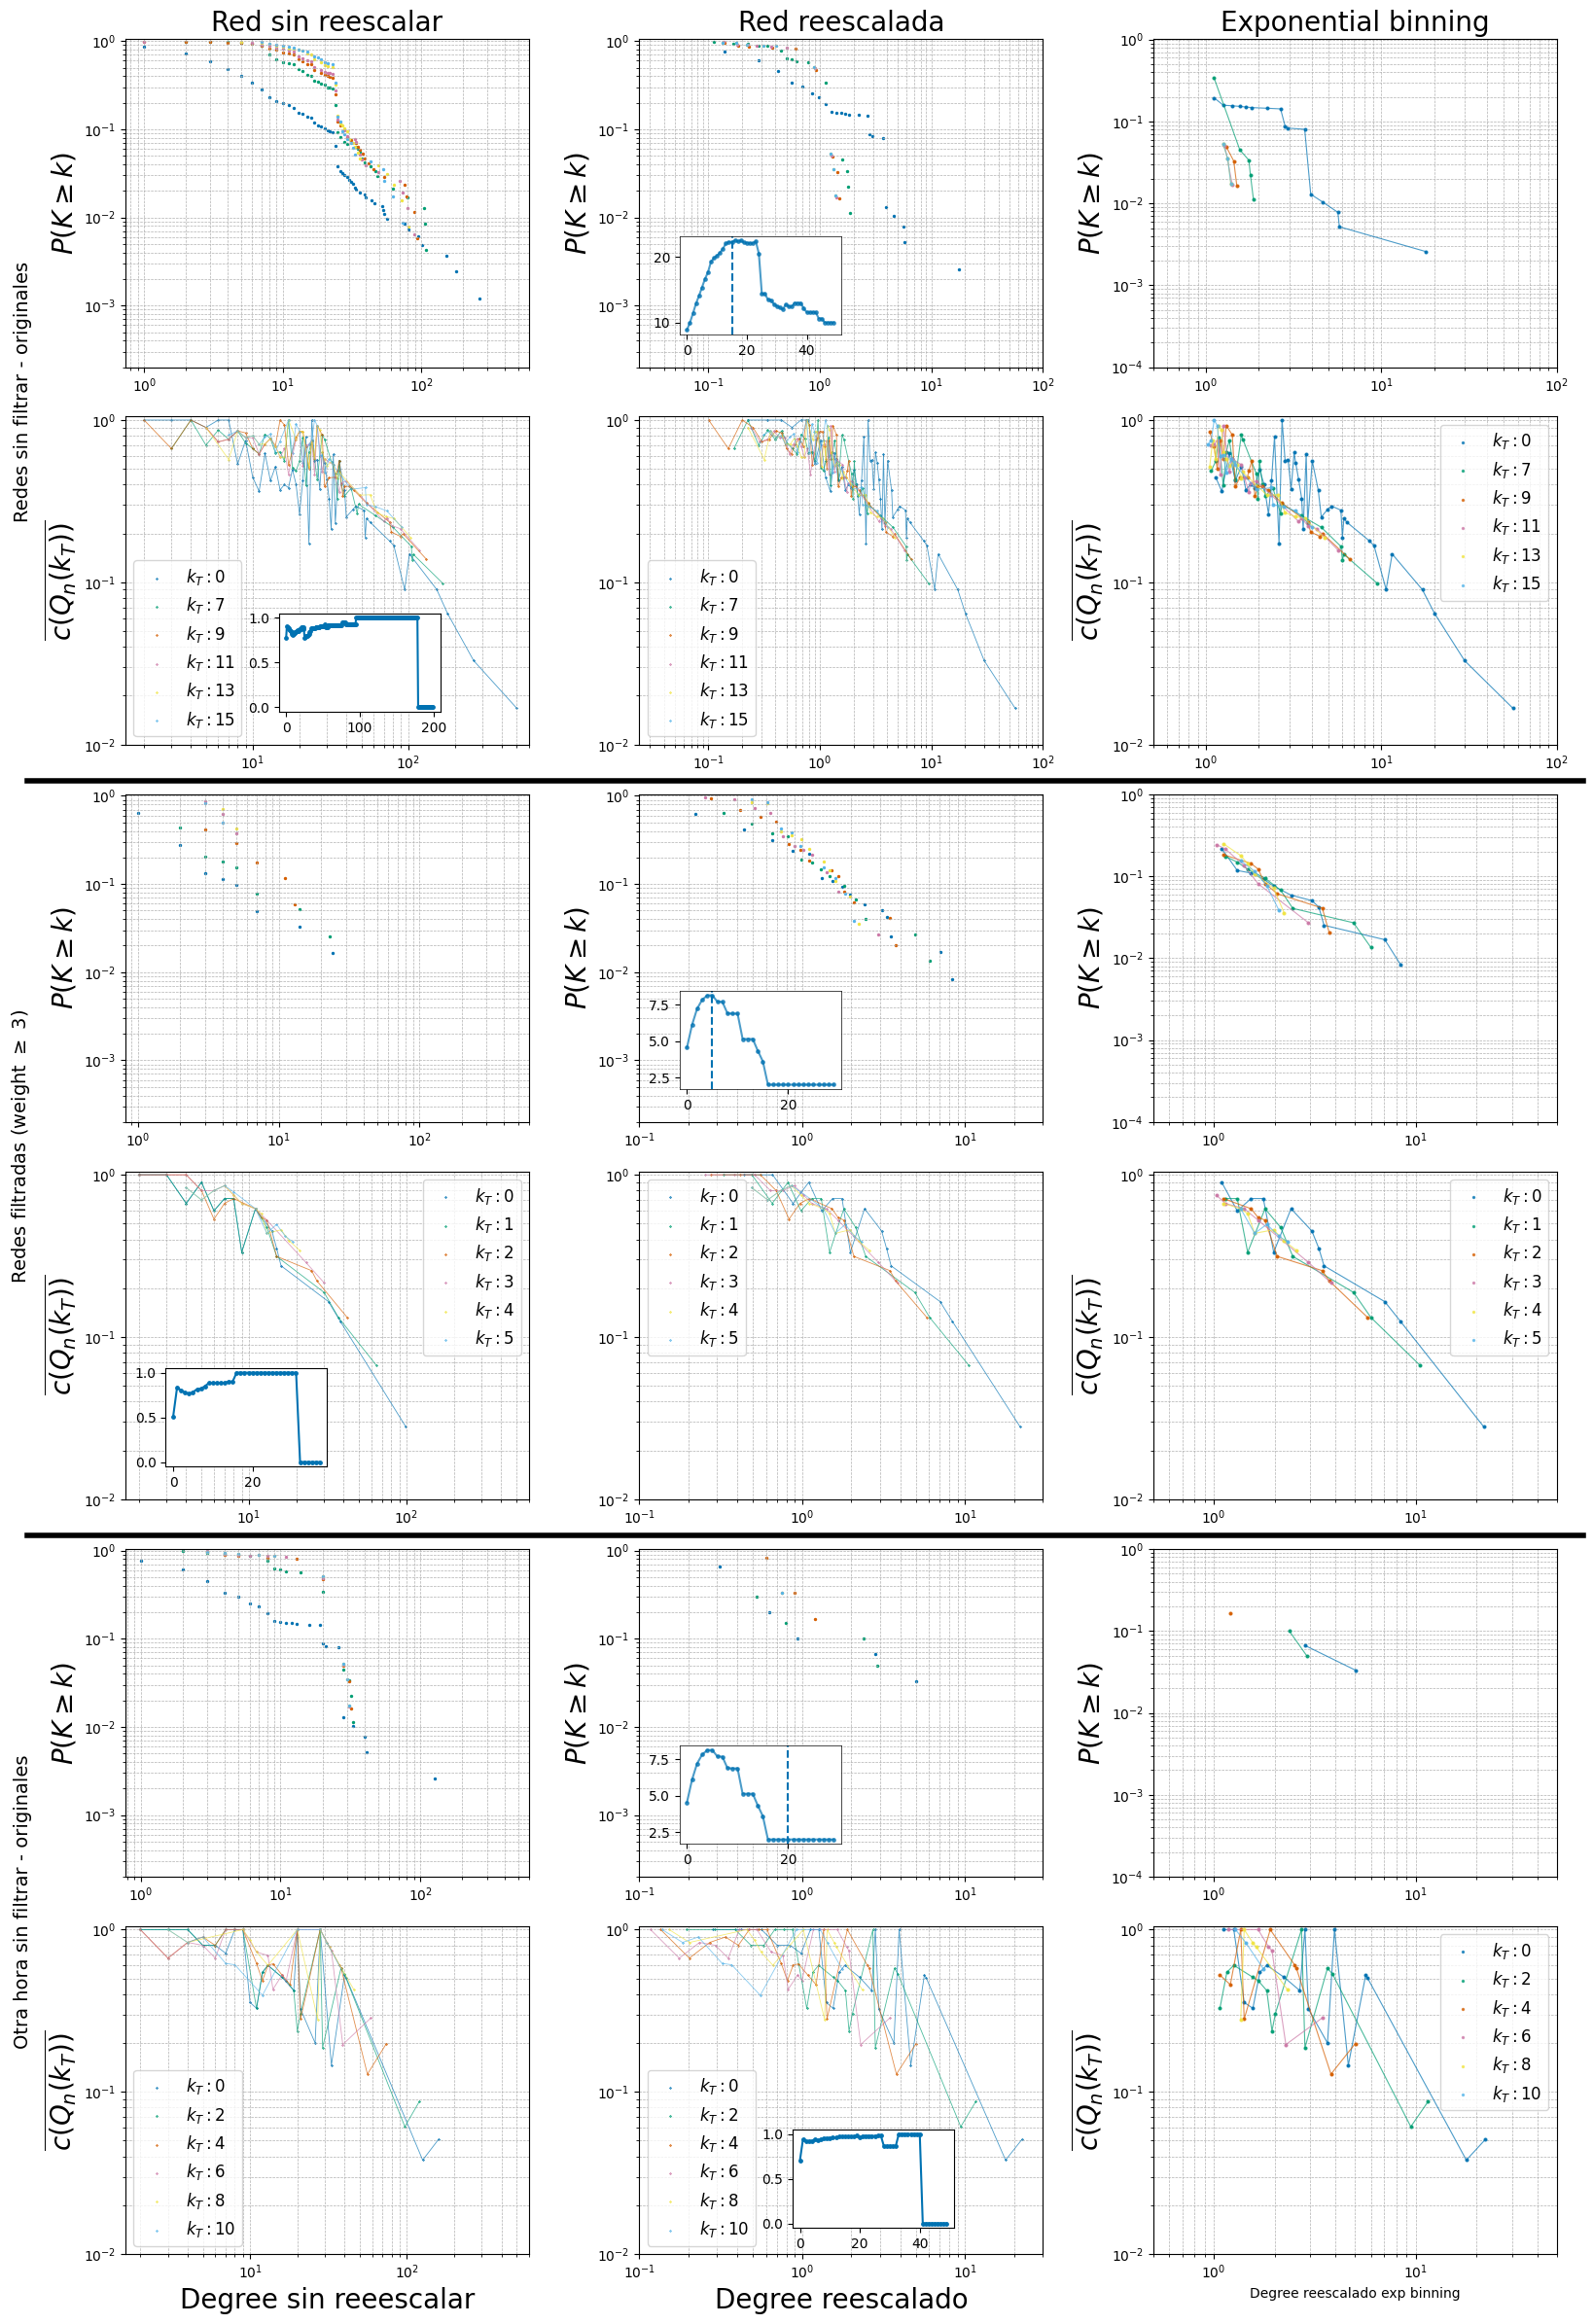

In [37]:
plt.style.use('seaborn-v0_8-colorblind')
from matplotlib.lines import Line2D

fig, axs = plt.subplots(6, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,24)


axs[0].set_title("Red sin reescalar", fontsize=20)
axs[1].set_title("Red reescalada", fontsize=20)
axs[2].set_title("Exponential binning", fontsize=20)

for ax in axs:
	ax.set_xlabel('')
# Ylabels: filas 1ª,3ª,5ª -> P(K>=k); filas 2ª,4ª,6ª -> overline c
for ax in [axs[0], axs[1], axs[2], axs[6], axs[7], axs[8], axs[12], axs[13], axs[14]]:
	ax.set_ylabel(r'$P(K\geq k)$', fontsize=20)
for ax in [axs[3], axs[4], axs[5], axs[9], axs[10], axs[11], axs[15], axs[16], axs[17]]:
	ax.set_ylabel(r'$\overline{c(Q_n(k_T))}$', fontsize=20)

# Red sin filtrar
## CCDF
### Sin reescalar

for index, points in enumerate(arr_ccdf_points_ch_h_noreescale):
	axs[0].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_kt_plot_ch_h[index])}")

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(ylim_ch_h_n[0], ylim_ch_h_n[1])
axs[0].set_xlim(xlim_ch_h_n[0], xlim_ch_h_n[1])
axs[0].grid(True, which="both", ls="--", linewidth=0.5)

#plot_avg_deg(axs[0].inset_axes([0.1, 0.1, 0.4, 0.3]), dict_avg_deg_ch_h_noreescale, limit_kt_ch_h, axvline=critical_kt_ch_h)
### Reescalando

for index, points in enumerate(arr_ccdf_points_ch_h):
	axs[1].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_kt_plot_ch_h[index])}")

axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(ylim_ch_h[0], ylim_ch_h[1])
axs[1].set_xlim(xlim_ch_h[0], xlim_ch_h[1])
axs[1].grid(True, which="both", ls="--", linewidth=0.5)

plot_avg_deg(axs[1].inset_axes([0.1, 0.1, 0.4, 0.3]), dict_avg_deg_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)

### Exp binning

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h,
                aa=1.02, ylim=(0.0001, 1.01), xlim=xlim_ch_h_e,
                marker="o", alpha=0.7, dot_size=2, line=True, normalize=False)
#plot_avg_deg(axs[2].inset_axes([0.15, 0.09, 0.5, 0.38]), dict_avg_deg_ch_h, 25, axvline=critical_kt_ch_h)


## Clustering self-similarity
### Sin reescalar

plot_clust_ss(axs[3], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h_noreescale, xlim=xlim_ch_h_n, ylim=(0.01, 1.05), ylabel=r"$\overline{c(Q_n(k_T))}$")
ax_inset = axs[3].inset_axes([0.38, 0.1, 0.4, 0.3])
ax_inset.plot(list(dict_thres_avg_clust_ch_h_noreescale.keys())[0:300], list(dict_thres_avg_clust_ch_h_noreescale.values())[0:300])
ax_inset.scatter(list(dict_thres_avg_clust_ch_h_noreescale.keys())[0:300], list(dict_thres_avg_clust_ch_h_noreescale.values())[0:300], s=6)

### Reescalando

plot_clust_ss(axs[4], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h, xlim=xlim_ch_h, ylim=(0.01, 1.05))
"""ax_inset = axs[4].inset_axes([0.38, 0.1, 0.4, 0.3])
ax_inset.plot(list(dict_thres_avg_clust_ch_h.keys())[0:300], list(dict_thres_avg_clust_ch_h.values())[0:300])
ax_inset.scatter(list(dict_thres_avg_clust_ch_h.keys())[0:300], list(dict_thres_avg_clust_ch_h.values())[0:300], s=6)"""

### Exp binning

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h,
                     aa=1.02, xlim=xlim_ch_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="o", linewidth=0.8, s=2)


# Red filtrada
## CCDF
### Sin reescalar

for index, points in enumerate(arr_ccdf_points_ch_f_noreescale):
	axs[6].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_kt_plot_ch_f[index])}")

axs[6].set_xscale('log')
axs[6].set_yscale('log')
axs[6].set_ylim(ylim_ch_f_n[0], ylim_ch_f_n[1])
axs[6].set_xlim(xlim_ch_f_n[0], xlim_ch_f_n[1])
axs[6].grid(True, which="both", ls="--", linewidth=0.5)


### Reescalando

for index, points in enumerate(arr_ccdf_points_ch_f):
	axs[7].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_ccdf_points_ch_f[index])}")

axs[7].set_xscale('log')
axs[7].set_yscale('log')
axs[7].set_ylim(0.0002, 1.05)
axs[7].set_xlim(xlim_ch_f[0], xlim_ch_f[1])
axs[7].grid(True, which="both", ls="--", linewidth=0.5)

plot_avg_deg(axs[7].inset_axes([0.1, 0.1, 0.4, 0.3]), dict_avg_deg_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)

### Exp binning

plot_pdf_expbin(axs[8], arr_ccdf_points_ch_f, arr_kt_plot_ch_f,
                aa=1.02, ylim=(0.0001, 1.01), xlim=xlim_ch_f_e,
                marker="o", alpha=0.7, dot_size=2, line=True, normalize=False)

## Clustering self-similarity
### Sin reescalar

plot_clust_ss(axs[9], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f_noreescale, xlim=xlim_ch_f_n, ylim=(0.01, 1.05), ylabel=r"$\overline{c(Q_n(k_T))}$")
ax_inset = axs[9].inset_axes([0.1, 0.1, 0.4, 0.3])
ax_inset.plot(list(dict_thres_avg_clust_ch_f_noreescale.keys())[0:300], list(dict_thres_avg_clust_ch_f_noreescale.values())[0:300])
ax_inset.scatter(list(dict_thres_avg_clust_ch_f_noreescale.keys())[0:300], list(dict_thres_avg_clust_ch_f_noreescale.values())[0:300], s=6)



### Reescalando

plot_clust_ss(axs[10], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f, xlim=xlim_ch_f, ylim=(0.01, 1.05))

### Exp binning

plot_clust_ss_expbin(axs[11], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f,
                     aa=1.02, xlim=xlim_ch_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="o", linewidth=0.8, s=2)


# Otra hora sin filtrar
## CCDF
### Sin reescalar

for index, points in enumerate(arr_ccdf_points_ch_o_noreescale):
	axs[12].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_kt_plot_ch_o[index])}")

axs[12].set_xscale('log')
axs[12].set_yscale('log')
axs[12].set_ylim(ylim_ch_o_n[0], ylim_ch_o_n[1])
axs[12].set_xlim(xlim_ch_o_n[0], xlim_ch_o_n[1])
axs[12].grid(True, which="both", ls="--", linewidth=0.5)

#plot_avg_deg(axs[0].inset_axes([0.1, 0.1, 0.4, 0.3]), dict_avg_deg_ch_h_noreescale, limit_kt_ch_h, axvline=critical_kt_ch_h)
### Reescalando

for index, points in enumerate(arr_ccdf_points_ch_o):
	axs[13].scatter(points[0], points[1], s=2, label=f"$k_t :$ {str(arr_kt_plot_ch_o[index])}")

axs[13].set_xscale('log')
axs[13].set_yscale('log')
axs[13].set_ylim(ylim_ch_o[0], ylim_ch_o[1])
axs[13].set_xlim(xlim_ch_o[0], xlim_ch_o[1])
axs[13].grid(True, which="both", ls="--", linewidth=0.5)

plot_avg_deg(axs[13].inset_axes([0.1, 0.1, 0.4, 0.3]), dict_avg_deg_ch_o, limit_kt_ch_o, axvline=critical_kt_ch_o)

### Exp binning

plot_pdf_expbin(axs[14], arr_ccdf_points_ch_o, arr_kt_plot_ch_o,
                aa=1.02, ylim=(0.0001, 1.01), xlim=xlim_ch_o_e,
                marker="o", alpha=0.7, dot_size=2, line=True, normalize=False)
				
#plot_avg_deg(axs[2].inset_axes([0.15, 0.09, 0.5, 0.38]), dict_avg_deg_ch_h, 25, axvline=critical_kt_ch_h)


## Clustering self-similarity
### Sin reescalar

plot_clust_ss(axs[15], arr_kt_plot_ch_o, dict_norm_int_deg_ch_o_noreescale, xlim=xlim_ch_o_n, ylim=(0.01, 1.05), ylabel=r"$\overline{c(Q_n(k_T))}$")


### Reescalando

plot_clust_ss(axs[16], arr_kt_plot_ch_o, dict_norm_int_deg_ch_o, xlim=xlim_ch_o, ylim=(0.01, 1.05))
ax_inset = axs[16].inset_axes([0.38, 0.08, 0.4, 0.3])
ax_inset.plot(list(dict_thres_avg_clust_ch_o.keys())[0:50], list(dict_thres_avg_clust_ch_o.values())[0:50])
ax_inset.scatter(list(dict_thres_avg_clust_ch_o.keys())[0:50], list(dict_thres_avg_clust_ch_o.values())[0:50], s=6)

### Exp binning

plot_clust_ss_expbin(axs[17], arr_kt_plot_ch_o, dict_norm_int_deg_ch_o,
                     aa=1.02, xlim=xlim_ch_o_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="o", linewidth=0.8, s=2)


axs[15].set_xlabel("Degree sin reeescalar")
axs[16].set_xlabel("Degree reescalado")
axs[17].set_xlabel("Degree reescalado exp binning")





plt.tight_layout()
# Líneas horizontales gruesas entre filas 2-3 y 4-5
y_line1 = (axs[5].get_position().ymin + axs[6].get_position().ymax) / 2 - 0.005
y_line2 = (axs[11].get_position().ymin + axs[12].get_position().ymax) / 2 - 0.005
fig.add_artist(Line2D([0, 1], [y_line1, y_line1], transform=fig.transFigure, color='black', linewidth=4))
fig.add_artist(Line2D([0, 1], [y_line2, y_line2], transform=fig.transFigure, color='black', linewidth=4))
# Etiquetas de grupo a la izquierda (entre filas)
x_left = axs[0].get_position().x0 - 0.06
y_12 = (axs[2].get_position().y0 + axs[3].get_position().y1) / 2
y_34 = (axs[8].get_position().y0 + axs[9].get_position().y1) / 2
y_56 = (axs[14].get_position().y0 + axs[15].get_position().y1) / 2
fig.text(x_left, y_12, "Redes sin filtrar - originales", rotation=90, ha='right', va='center', fontsize=14)
fig.text(x_left, y_34, "Redes filtradas (weight $\\geq$ 3)", rotation=90, ha='right', va='center', fontsize=14)
fig.text(x_left, y_56, "Otra hora sin filtrar - originales", rotation=90, ha='right', va='center', fontsize=14)

fig.savefig("plots/self_similarity_check_ch.png", dpi=300)
plt.show()
